# 🩺 Fine-tuning médical LoRA (QLoRA) — TechCorp
**Filière IA — Mission Expérimentale (Challenge IA 7h, Ynov).**

Fine-tuning **LoRA** d'un modèle de base sur le **dataset médical nettoyé par la filière DATA**
(`ruslanmv/ai-medical-chatbot`, mappé `Patient→instruction` / `Doctor→output`).

**Livrables attendus :** ce notebook (lien Colab) + les **métriques d'entraînement** (loss, epochs/steps).

> ⚠️ Modèle **expérimental**, **pas pour la production**. Ne remplace jamais un avis médical.

⚠️ **Runtime GPU obligatoire** : *Exécution → Modifier le type d'exécution → T4 GPU*.

## 0. Environnement & configuration

In [1]:
!nvidia-smi

Wed Jul  1 09:55:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip -q install "transformers>=4.44,<4.47" "peft>=0.13.0" "accelerate>=0.34.0" bitsandbytes datasets pyarrow matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 68.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [3]:
# --- Configuration (modifiable) ---
BASE_MODEL = "microsoft/Phi-3-mini-4k-instruct"   # cf. medical_project/Readme.md (Phi-3.x recommandé)
N_TRAIN   = 2000     # nb d'exemples médicaux pour l'entraînement POC
MAX_STEPS = 250      # borne le temps d'entraînement sur T4 (~15-20 min)
MAX_SEQ   = 512      # longueur max de séquence
SEED      = 42

## 1. Données — dataset médical nettoyé (pipeline DATA)

Reprise de la logique de `rendu/data/preparation_medical.py` : téléchargement du dataset,
nettoyage (encodage, HTML, redirections publicitaires), filtres qualité, déduplication.

In [4]:
import os, re, json, random, unicodedata, urllib.request
import pandas as pd

URL = "https://huggingface.co/datasets/ruslanmv/ai-medical-chatbot/resolve/main/dialogues.parquet"
if not os.path.exists("dialogues.parquet"):
    print("Téléchargement du dataset médical (~142 Mo)...")
    urllib.request.urlretrieve(URL, "dialogues.parquet")
df = pd.read_parquet("dialogues.parquet", columns=["Patient", "Doctor"])
print("Dialogues bruts :", len(df))

# --- Nettoyage (identique à la filière DATA) ---
HTML   = re.compile(r"<[^>]+>")
REDIR  = re.compile(r"\s*(for (further|more) information\s*)?consult[^.]*?-+>+\s*$", re.I)
ARROW  = re.compile(r"\s*-+>+\s*")
BAD    = re.compile("[\ufffd\xa0\u200b]")

def clean(t):
    t = str(t)
    t = BAD.sub(" ", t)
    t = HTML.sub(" ", t)
    t = REDIR.sub("", t)
    t = ARROW.sub(" ", t)
    t = unicodedata.normalize("NFC", t)
    t = re.sub(r"[ \t]+", " ", t)
    return t.strip()

df["instruction"] = df["Patient"].map(clean)
df["output"]      = df["Doctor"].map(clean)
df = df[(df.instruction.str.len() >= 15) & (df.output.str.len() >= 25)]
df = df[(df.instruction.str.len() + df.output.str.len()) <= 2000]
df = df.drop_duplicates(["instruction", "output"])

records = df[["instruction", "output"]].to_dict("records")
random.seed(SEED); random.shuffle(records)
train_records = records[:N_TRAIN]
print(f"Propre : {len(records)}  ->  entraînement POC : {len(train_records)}")
print(train_records[0])

Téléchargement du dataset médical (~142 Mo)...
Dialogues bruts : 256916
Propre : 237396  ->  entraînement POC : 2000
{'instruction': 'I am having pain, burning, numbness on my left side from the buttock area all the way to the feet. At night, I have difficulty getting comfortable and find that along with the problems listed previously, my left hand/arm is sometimes numb as well. What is going on?', 'output': 'hi,thank you for providing the brief history of you.A thorough neuromuscular assessment is advised.As mentioned by you about the symptoms of pain, burning sensation and numbness a thorough detailed neuromuscular assessment is a must. Post which an MRI of the cervical and lumbar spine will be performed as to which will help us to understand the extent of the soft tissue Injury and the nerve impingement. The symptoms you are mentioning is direct towards the pinched nerve. So for getting a closer confirmed look an MRI is needed.Also, after all these, Medication for pain relief and ph

## 2. Modèle de base + LoRA (QLoRA 4-bit)

In [5]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

tok = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "right"

bnb = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
)
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, quantization_config=bnb, device_map="auto", trust_remote_code=True,
)
model = prepare_model_for_kbit_training(model)

lora = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, bias='none', task_type='CAUSAL_LM',
    target_modules=['qkv_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
)
model = get_peft_model(model, lora)
model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

trainable params: 15,204,352 || all params: 3,836,283,904 || trainable%: 0.3963


## 3. Tokenisation

In [6]:
from datasets import Dataset

def to_text(r):
    return f"<|user|>\n{r['instruction']}<|end|>\n<|assistant|>\n{r['output']}<|end|>"

ds = Dataset.from_list([{"text": to_text(r)} for r in train_records])

def tok_fn(batch):
    return tok(batch["text"], truncation=True, max_length=MAX_SEQ)

ds = ds.map(tok_fn, batched=True, remove_columns=["text"])
print(ds)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 2000
})


## 4. Entraînement + métriques

In [7]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

args = TrainingArguments(
    output_dir="medical_lora",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    warmup_steps=20,
    max_steps=MAX_STEPS,
    logging_steps=10,
    save_strategy="no",
    fp16=True,
    report_to="none",
)
collator = DataCollatorForLanguageModeling(tok, mlm=False)
trainer = Trainer(model=model, args=args, train_dataset=ds, data_collator=collator)
trainer.train()

max_steps is given, it will override any value given in num_train_epochs
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,2.782100
20,2.563100
30,2.469600
40,2.337700
50,2.472300
60,2.461400
70,2.373300
80,2.429800
90,2.250700
100,2.322600


TrainOutput(global_step=250, training_loss=2.378803367614746, metrics={'train_runtime': 1375.341, 'train_samples_per_second': 1.454, 'train_steps_per_second': 0.182, 'total_flos': 1.2703065847320576e+16, 'train_loss': 2.378803367614746, 'epoch': 1.0})

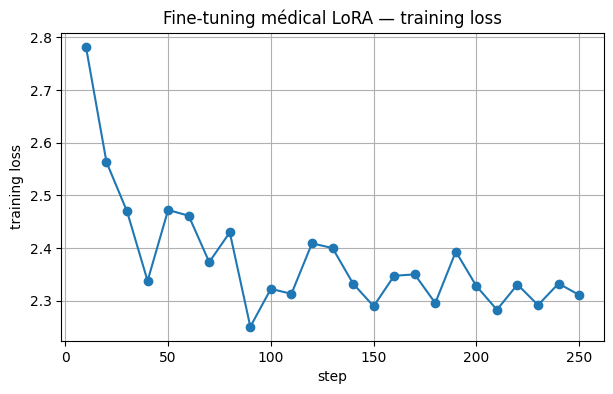

Loss initiale : 2.7821
Loss finale   : 2.3110
Steps         : 250  |  exemples : 2000


In [8]:
# Courbe de loss (métrique demandée)
import matplotlib.pyplot as plt
hist = trainer.state.log_history
steps = [h["step"] for h in hist if "loss" in h]
loss  = [h["loss"] for h in hist if "loss" in h]
plt.figure(figsize=(7,4))
plt.plot(steps, loss, marker="o")
plt.xlabel("step"); plt.ylabel("training loss")
plt.title("Fine-tuning médical LoRA — training loss")
plt.grid(True); plt.show()

print(f"Loss initiale : {loss[0]:.4f}" if loss else "n/a")
print(f"Loss finale   : {loss[-1]:.4f}" if loss else "n/a")
print(f"Steps         : {steps[-1] if steps else 0}  |  exemples : {len(train_records)}")

## 5. Sauvegarde de l'adaptateur

In [9]:
model.save_pretrained("medical_lora_adapter")
tok.save_pretrained('medical_lora_adapter')
print("Adaptateur LoRA médical sauvegardé dans ./medical_lora_adapter")
# Optionnel : monter Google Drive pour conserver l'adaptateur
# from google.colab import drive; drive.mount('/content/drive')
# !cp -r medical_lora_adapter /content/drive/MyDrive/

Adaptateur LoRA médical sauvegardé dans ./medical_lora_adapter


## 6. Test qualitatif (après fine-tuning)

In [10]:
model.eval()
@torch.no_grad()
def ask_med(m, max_new_tokens=160):
    p = f'<|user|>\n{m}<|end|>\n<|assistant|>\n'
    i = tok(p, return_tensors='pt').to(model.device)
    o = model.generate(**i, max_new_tokens=max_new_tokens, do_sample=False,
                       repetition_penalty=1.1, pad_token_id=tok.eos_token_id,
                       eos_token_id=tok.eos_token_id)
    return tok.decode(o[0][i['input_ids'].shape[1]:], skip_special_tokens=True).strip()

tests = [
    'I have had a headache and mild fever for two days. What should I do?',
    'What are common causes of lower back pain?',
    'Is it safe to take ibuprofen if I have high blood pressure?',
]
for q in tests:
    print('Q:', q)
    print('R:', ask_med(q))
    print('-' * 90)

The `seen_tokens` attribute is deprecated and will be removed in v4.41. Use the `cache_position` model input instead.
`get_max_cache()` is deprecated for all Cache classes. Use `get_max_cache_shape()` instead. Calling `get_max_cache()` will raise error from v4.48


Q: I have had a headache and mild fever for two days. What should I do?


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


R: Hello,Thanks for using health care magicI understand your concernYou can take paracetamol 500mg every four hours to relieve the pain of headache . You may also use ibuprofen or aspirin if you are not allergic to them as they will help in reducing inflammation too , which is causing this symptomHope my answer helps...Wish you good health..RegardsDr Suresh Kumar MD (General & Family Physician)
------------------------------------------------------------------------------------------
Q: What are common causes of lower back pain?
R: Hello,Thanks for using health care magic.Lower Back Pain is a very common problem and can be caused by many reasons like muscle strain or sprain due to heavy lifting , poor posture while sitting/standing etc., disc prolapse (disc herniation) which compresses the nerve roots causing sciatica type symptoms in legs with numbness / tingling sensations as well as weakness if severe enough . Other possible cause includes osteoarthritis where there may not have any

## 7. Conclusion & livrables

- **Modèle :** base Phi-3-mini + adaptateur **LoRA médical** (QLoRA 4-bit).
- **Données :** dataset médical nettoyé par la filière DATA (mapping instruction/output).
- **Métriques :** voir la courbe de loss et les valeurs (loss initiale/finale, steps) en section 4.

**Pour livrer le lien Colab :** *Fichier → Enregistrer une copie dans Drive*, puis *Partager* le
lien (accès lecture). Ajouter ce lien + une capture de la courbe de loss au rendu Moodle.

> ⚠️ **Modèle expérimental, non destiné à la production.** Toute réponse médicale doit être
> validée par un professionnel de santé. Voir `medical_project/Readme.md` (RGPD, anonymisation,
> validation clinique).